In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer
import torch as pt
import re
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [ ]:
def scale_data(dataframe, oversample=False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x, y)

  data = np.hstack((x, np.reshape(y, (-1, 1))))

  return data, x, y

In [ ]:
df = pd.read_csv("preprocessed_datasets/bert_features_with_labels.csv")

In [ ]:
train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)

In [ ]:
print(f"Total rows in dataset: {len(df)}")
print(f"Total rows in train set: {len(train)}")
print(f"Total rows in test set: {len(test)}")

print("\nClass distribution in full dataset:")
print(df['label'].value_counts())

print("\nClass distribution in train set:")
print(train['label'].value_counts())

print("\nClass distribution in test set:")
print(test['label'].value_counts())

Total rows in dataset: 14336
Total rows in train set: 11469
Total rows in test set: 2867

Class distribution in full dataset:
label
1    7511
0    6825
Name: count, dtype: int64

Class distribution in train set:
label
1    5984
0    5485
Name: count, dtype: int64

Class distribution in test set:
label
1    1527
0    1340
Name: count, dtype: int64


In [ ]:
train, xtrain, ytrain = scale_data(train)
test, xtest, ytest = scale_data(test)

In [ ]:
print(f"xtrain shape: {xtrain.shape}")
print(f"ytrain shape: {ytrain.shape}")
print(f"xtest shape: {xtest.shape}")
print(f"ytest shape: {ytest.shape}")

xtrain shape: (11469, 768)
ytrain shape: (11469,)
xtest shape: (2867, 768)
ytest shape: (2867,)


In [ ]:
print(sum(ytrain == 1))
print(sum(ytrain == 0))

print(sum(ytest == 1))
print(sum(ytest == 0))

5984
5485
1527
1340


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(xtrain, ytrain)

ypred = knn_model.predict(xtest)
print(ypred)
print(ytest)
print(classification_report(ytest, ypred))

[1 1 1 ... 1 0 1]
[1 1 1 ... 1 0 1]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1340
           1       0.90      0.90      0.90      1527

    accuracy                           0.90      2867
   macro avg       0.89      0.89      0.89      2867
weighted avg       0.90      0.90      0.90      2867



In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model = nb_model.fit(xtrain, ytrain)

ypred = nb_model.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.79      0.78      0.78      1340
           1       0.81      0.81      0.81      1527

    accuracy                           0.80      2867
   macro avg       0.80      0.80      0.80      2867
weighted avg       0.80      0.80      0.80      2867



In [ ]:
from sklearn.linear_model import LogisticRegression

lgr_model = LogisticRegression()
lgr_model = lgr_model.fit(xtrain, ytrain)

ypred = lgr_model.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1340
           1       0.95      0.94      0.94      1527

    accuracy                           0.94      2867
   macro avg       0.94      0.94      0.94      2867
weighted avg       0.94      0.94      0.94      2867



/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.svm import SVC

svc_model = SVC()
svc_model = svc_model.fit(xtrain, ytrain)

ypred = svc_model.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1340
           1       0.96      0.94      0.95      1527

    accuracy                           0.95      2867
   macro avg       0.95      0.95      0.95      2867
weighted avg       0.95      0.95      0.95      2867



In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model = xgb_model.fit(xtrain, ytrain)

ypred = xgb_model.predict(xtest)
print(classification_report(ytest, ypred))

/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [14:14:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1340
           1       0.93      0.92      0.92      1527

    accuracy                           0.92      2867
   macro avg       0.92      0.92      0.92      2867
weighted avg       0.92      0.92      0.92      2867



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(xtrain, ytrain)

ypred = rf_model.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1340
           1       0.88      0.87      0.88      1527

    accuracy                           0.87      2867
   macro avg       0.87      0.87      0.87      2867
weighted avg       0.87      0.87      0.87      2867



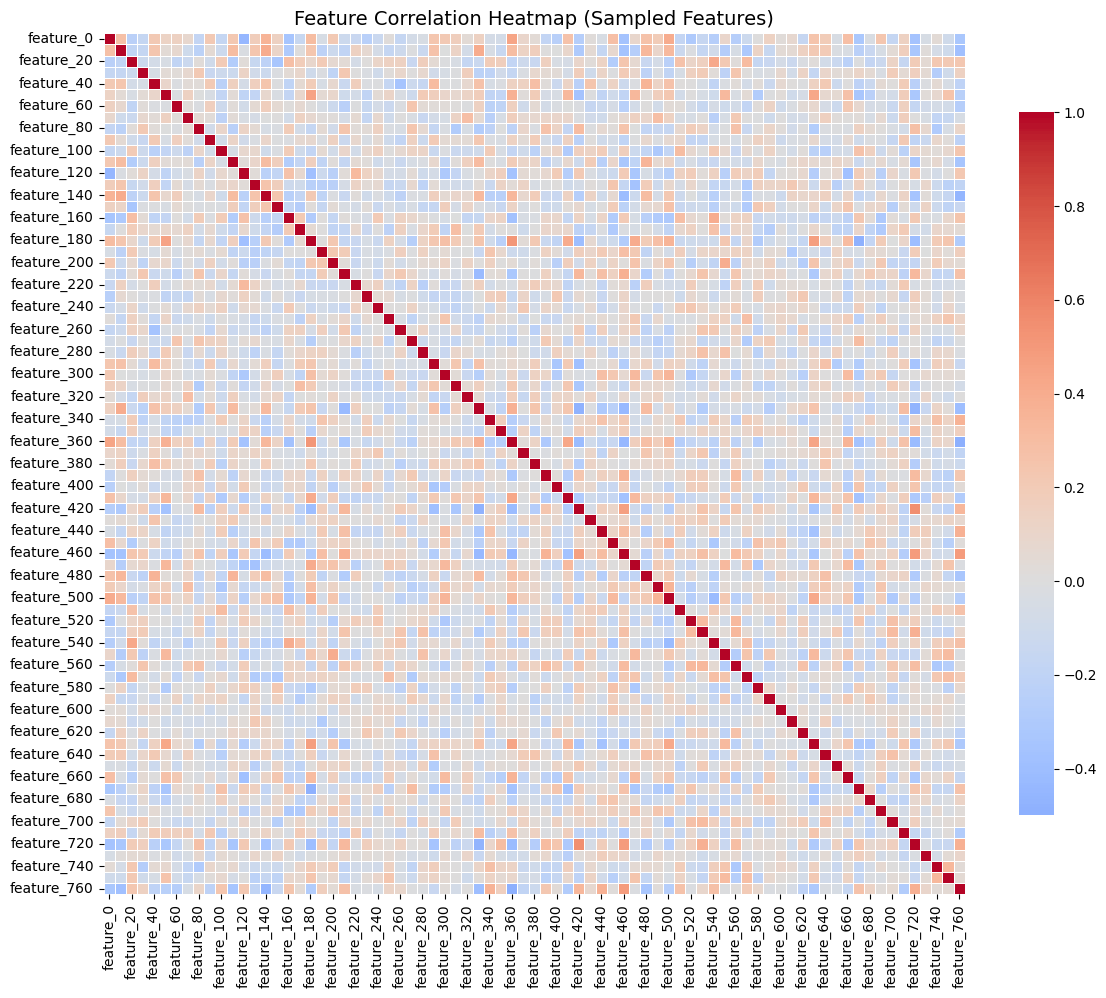

In [ ]:
feature_cols = [col for col in df.columns if col.startswith('feature_')]
sample_features = feature_cols[::10]  # Every 10th feature

corr_matrix = df[sample_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Sampled Features)', fontsize=14)
plt.tight_layout()
plt.show()

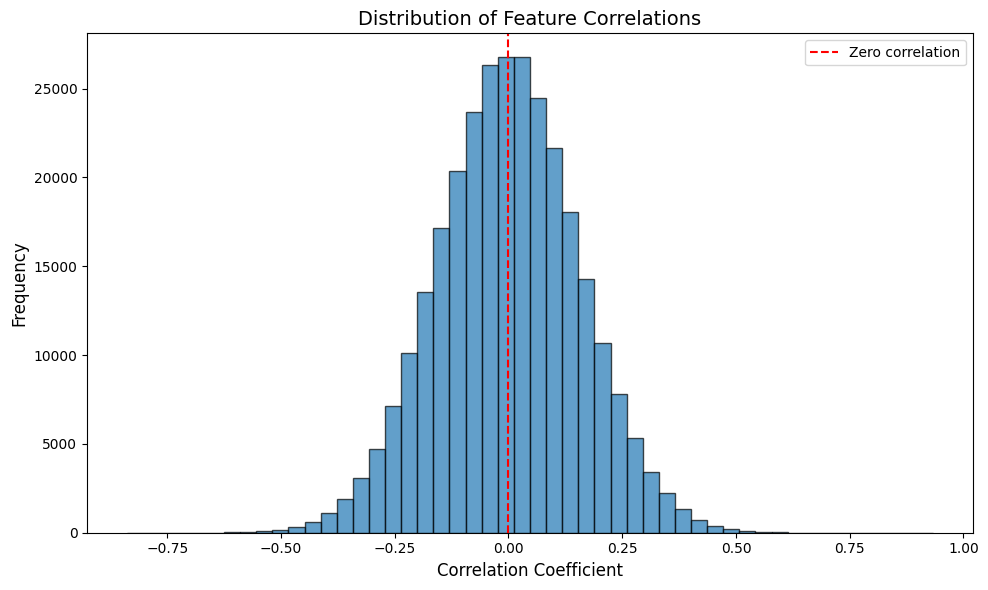

Mean correlation: -0.0012
Median correlation: -0.0009
Max correlation: 0.9323
Min correlation: -0.8374


In [ ]:
all_corr = df[feature_cols].corr()
corr_values = all_corr.values[np.triu_indices_from(all_corr.values, k=1)]

plt.figure(figsize=(10, 6))
plt.hist(corr_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Feature Correlations', fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', label='Zero correlation')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean correlation: {corr_values.mean():.4f}")
print(f"Median correlation: {np.median(corr_values):.4f}")
print(f"Max correlation: {corr_values.max():.4f}")
print(f"Min correlation: {corr_values.min():.4f}")

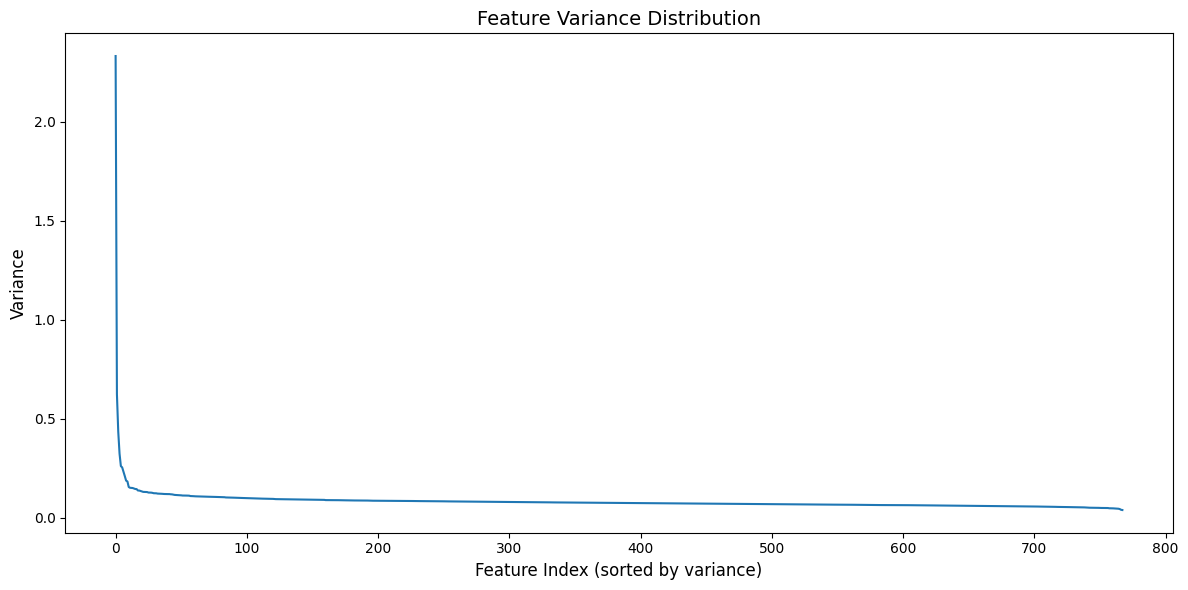


Top 10 most variable features:
feature_752    2.330459
feature_273    0.623656
feature_667    0.435791
feature_308    0.324116
feature_109    0.261628
feature_142    0.254951
feature_588    0.233937
feature_46     0.211081
feature_562    0.188172
feature_94     0.184168
dtype: float64


In [ ]:
variances = df[feature_cols].var().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(range(len(variances)), variances.values)
plt.xlabel('Feature Index (sorted by variance)', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.title('Feature Variance Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nTop 10 most variable features:")
print(variances.head(10))

In [4]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

# 1. Setup Device (MPS for Mac, CUDA for Nvidia, CPU otherwise)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

# 2. Load and Prepare Data
# Load one of your processed datasets
df = pd.read_csv("processed_datasets/WELFake_Dataset_processed.csv").dropna()

# Optional: Sample data for faster testing/debugging
# df = df.sample(2000, random_state=42) 

# Split into train and validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['combined_text'].tolist(), 
    df['label'].tolist(), 
    test_size=0.2, 
    random_state=42
)

# 3. Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize the text
# truncation=True: Cut text longer than max_length
# padding=True: Pad shorter text to max_length
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

# 4. Create PyTorch Dataset
class FakeNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = FakeNewsDataset(train_encodings, train_labels)
val_dataset = FakeNewsDataset(val_encodings, val_labels)

# 5. Load Pre-trained BERT Model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model.to(device)

# 6. Define Training Arguments
training_args = TrainingArguments(
    output_dir='./results',          # Output directory
    num_train_epochs=3,              # Total number of training epochs
    per_device_train_batch_size=16,  # Batch size per device during training (8 or 16 for M1)
    per_device_eval_batch_size=64,   # Batch size for evaluation
    warmup_steps=500,                # Number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # Strength of weight decay
    logging_dir='./logs',            # Directory for storing logs
    logging_steps=10,
    eval_strategy="epoch",           # Evaluate every epoch
    save_strategy="epoch",           # Save checkpoint every epoch
    load_best_model_at_end=True,     # Load the best model when finished
)

# 7. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# 8. Train the Model
trainer.train()

# 9. Save the Final Model
model.save_pretrained("./fake_news_bert_model")
tokenizer.save_pretrained("./fake_news_bert_model")
print("Training complete and model saved.")

Using MPS (Apple Silicon GPU)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 